# Yeo-Johnson Transformation

Yeo-Johnson Transformation is a power transformation technique used to reduce skewness and make numerical features more normally distributed.

It is similar to Box-Cox Transformation, but it has an important advantage:

**Yeo-Johnson can handle positive values, zero, and negative values.**

The transformation automatically estimates an optimal lambda (λ) value.

It is useful when a numerical feature is highly skewed and contains zero or negative values.

## Why Do We Need Yeo-Johnson Transformation?

Many real-world numerical features are not normally distributed.

They may contain:

- Right skewness
- Left skewness
- Zero values
- Negative values
- Extreme observations

Box-Cox Transformation requires strictly positive values.

Yeo-Johnson is more flexible because it can transform features containing:

- Positive values
- Zero
- Negative values

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Feature": [
        -100,
        -50,
        -20,
        -5,
        0,
        2,
        5,
        20,
        50,
        200
    ]
})

df

,Feature
0,-100
1,-50
2,-20
3,-5
4,0
5,2
6,5
7,20
8,50
9,200


In [2]:
print("Original Skewness:")
print(df["Feature"].skew())

Original Skewness:
1.5522619101644952


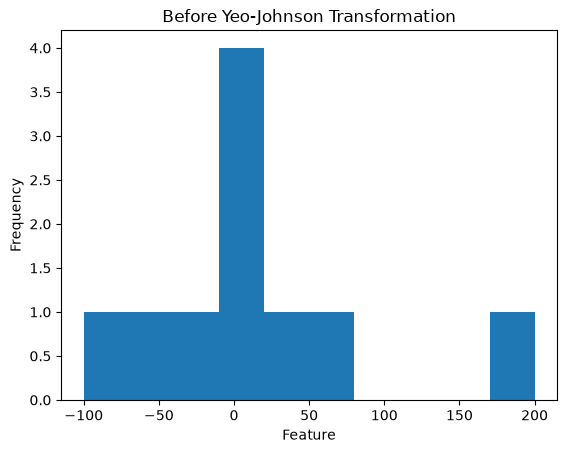

In [3]:
import matplotlib.pyplot as plt

plt.hist(df["Feature"], bins=10)

plt.title("Before Yeo-Johnson Transformation")
plt.xlabel("Feature")
plt.ylabel("Frequency")

plt.show()

## Why Not Box-Cox Transformation?

Box-Cox Transformation requires all values to be strictly positive.

Our feature contains:

- Negative values
- Zero
- Positive values

Therefore, Box-Cox cannot be directly applied.

Yeo-Johnson is suitable because it can handle all three types of values.

## Applying Yeo-Johnson Transformation

Scikit-learn provides `PowerTransformer`.

By setting:

method="yeo-johnson"

the transformer automatically estimates the optimal lambda (λ) value and applies the transformation.

In [4]:
from sklearn.preprocessing import PowerTransformer

transformer = PowerTransformer(
    method="yeo-johnson"
)

transformed = transformer.fit_transform(
    df[["Feature"]]
)

transformed[:5]

array([[-2.00406359],
       [-0.92405001],
       [-0.31638304],
       [-0.0373642 ],
       [ 0.04529522]])

In [5]:
df["Feature_YeoJohnson"] = transformed

df

,Feature,Feature_YeoJohnson
0,-100,-2.004064
1,-50,-0.924050
2,-20,-0.316383
3,-5,-0.037364
4,0,0.045295
5,2,0.073670
6,5,0.113309
7,20,0.294510
8,50,0.627175
9,200,2.127901


In [6]:
print("Learned Lambda:")
print(transformer.lambdas_)

Learned Lambda:
[0.91521215]


In [7]:
print("Original Skewness:")
print(df["Feature"].skew())

print("\nYeo-Johnson Skewness:")
print(df["Feature_YeoJohnson"].skew())

Original Skewness:
1.5522619101644952

Yeo-Johnson Skewness:
0.12328730553060337


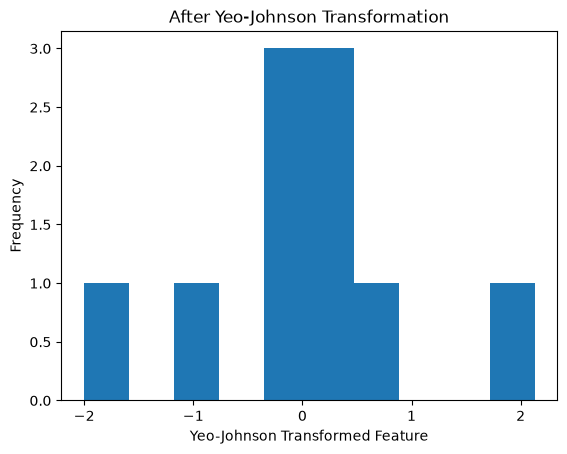

In [8]:
plt.hist(
    df["Feature_YeoJohnson"],
    bins=10
)

plt.title("After Yeo-Johnson Transformation")
plt.xlabel("Yeo-Johnson Transformed Feature")
plt.ylabel("Frequency")

plt.show()